First: lets see we want to take account for what our current un-tidy data set looks like:

In [56]:
#import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
sns.set_theme(style='ticks')

#Load the dataset and take a look at the first five rows
df = pd.read_csv("fed_rd_year&gdp.csv")
print(f'the data is currently {df.shape[0]} units long and has {df.shape[1]} columns')
df.head()


the data is currently 14 units long and has 43 columns


,department,1976_gdp1790000000000.0,1977_gdp2028000000000.0,1978_gdp2278000000000.0,1979_gdp2570000000000.0,1980_gdp2797000000000.0,1981_gdp3138000000000.0,1982_gdp3314000000000.0,1983_gdp3541000000000.0,1984_gdp3953000000000.0,...,2008_gdp14752000000000.0,2009_gdp14415000000000.0,2010_gdp14799000000000.0,2011_gdp15379000000000.0,2012_gdp16027000000000.0,2013_gdp16516000000000.0,2014_gdp17244000000000.0,2015_gdp17983000000000.0,2016_gdp18470000000000.0,2017_gdp19177000000000.0
0,DHS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1155000000,1258000000,1009000000,848000000,527000000,737000000,1092000000,960000000,602000000,735000000
1,DOC,8.190000e+08,8.370000e+08,8.710000e+08,9.520000e+08,9.450000e+08,8.290000e+08,6.930000e+08,7.000000e+08,7.550000e+08,...,1379000000,1594000000,1521000000,1357000000,1373000000,1397000000,1641000000,1596000000,1730000000,1824000000
2,DOD,3.569600e+10,3.796700e+10,3.702200e+10,3.717400e+10,3.700500e+10,4.173700e+10,4.689300e+10,5.100800e+10,5.813900e+10,...,94247000000,93527000000,94325000000,88220000000,81543000000,70583000000,70341000000,69522000000,75213000000,51862000000
3,DOE,1.088200e+10,1.374100e+10,1.566300e+10,1.561200e+10,1.522600e+10,1.479800e+10,1.216000e+10,1.112900e+10,1.173100e+10,...,11343000000,11823000000,12329000000,11902000000,11839000000,11528000000,12686000000,15033000000,15504000000,15032000000
4,DOT,1.142000e+09,1.095000e+09,1.156000e+09,1.004000e+09,1.048000e+09,9.780000e+08,7.020000e+08,8.000000e+08,1.018000e+09,...,1016000000,1062000000,1221000000,1064000000,1007000000,881000000,843000000,926000000,910000000,936000000


⭐ We can see that the data is 14 by 43 and has current header names of "department" as well as each year combined with it's GDP value

Now lets check for any missing values in the data to ensure our set is not bias and we will not distort our conculsions

In [57]:
#check for missing values
df_null_counts = df.isnull().sum()
print(df_null_counts)

department                  0
1976_gdp1790000000000.0     1
1977_gdp2028000000000.0     1
1978_gdp2278000000000.0     1
1979_gdp2570000000000.0     1
1980_gdp2797000000000.0     1
1981_gdp3138000000000.0     1
1982_gdp3314000000000.0     1
1983_gdp3541000000000.0     1
1984_gdp3953000000000.0     1
1985_gdp4270000000000.0     1
1986_gdp4536000000000.0     1
1987_gdp4782000000000.0     1
1988_gdp5155000000000.0     1
1989_gdp5570000000000.0     1
1990_gdp5915000000000.0     1
1991_gdp6110000000000.0     1
1992_gdp6435000000000.0     1
1993_gdp6795000000000.0     1
1994_gdp7198000000000.0     1
1995_gdp7583000000000.0     1
1996_gdp7978000000000.0     1
1997_gdp8483000000000.0     1
1998_gdp8955000000000.0     1
1999_gdp9511000000000.0     1
2000_gdp10148000000000.0    1
2001_gdp10565000000000.0    1
2002_gdp10877000000000.0    0
2003_gdp11332000000000.0    0
2004_gdp12089000000000.0    0
2005_gdp12889000000000.0    0
2006_gdp13685000000000.0    0
2007_gdp14323000000000.0    0
2008_gdp14

⭐ At this point we can make two observations: 

1. This data frame is messy according to Wickham's piece because the column headers are values and not variable names (which should instead be years). We also have multiple variables stored in one column (year number and a gdp figure), which violates tidy data. 
2. There are missing values in the data frame from years 1976 to year 2001 in the DHS department. After further research, I uncovered that the department of homeland security was created in 2002, as a response for the 2001 9/11 terrorist attack. This means the data is missing not at random because the information simply did not exsist before. To fill these gaps we will imput 0's to aid in future analysis.


Now we will tidy the data to ensure: 
1. Each variable forms a column.
2. Each observation forms a row.
3. Each type of observational unit forms a table.

In [ ]:

# create a new tidy data frame with the year, gdp, department, and rd_budget columns by using method chaining
df_tidy = (
    df
    # appease tidy data critera 1 & 2 by melting the wide year_gdp columns into a single column and 
    # then spliting that column into two separate columns (year and gdp)
    .melt(id_vars=['department'], var_name='year_gdp', value_name='rd_budget')
    .assign(
       # Extract the year from the string by splitting on '_gdp' and taking the left side
       year=lambda x: x['year_gdp'].str.split('_gdp').str[0],
       # Extract the gdp figure from the string by splitting on '_gdp' and taking the right side
       gdp=lambda x: x['year_gdp'].str.split('_gdp').str[1].str.replace('.0','', regex=False)
    )
    # make sure each observational unit is not a string and is instead a numeric value
    .astype({'year': int, 'gdp': float})
    # drop the redundant year_gdp column that we no longer need
    .drop(columns=['year_gdp'])

    .assign(
    # convert the rd_budget and gdp columns from dollars to billions of dollars for easier interpretation
        rd_budget=lambda x: x['rd_budget'] / 1e9,
        gdp=lambda x: x['gdp'] / 1e9)
    # rename the columns 
    [['year', 'gdp', 'department', 'rd_budget']]
    # fill the missing values in the r_dbudget column with 0 since a missing value seems to tell us there is no r_d budget for that department in that year
    .fillna({'rd_budget': 0})
)   
# seperate data frames to show the gdp for each year by dropping duplicates
gdp_by_year = df_tidy[['year', 'gdp']].drop_duplicates()

# reorder the columns to make it easier to read and interpret
dept_rd = df_tidy[['year', 'department', 'rd_budget']]
print(f'New tidy data frame containing the R&D budget for each department by year:\n{dept_rd}')

print("\nData frame containing the GDP for each year:")
print(gdp_by_year)


New tidy data frame containing the R&D budget for each department by year:
     year department  rd_budget
0    1976        DHS      0.000
1    1976        DOC      0.819
2    1976        DOD     35.696
3    1976        DOE     10.882
4    1976        DOT      1.142
..    ...        ...        ...
583  2017        NIH     33.052
584  2017        NSF      6.040
585  2017      Other      1.553
586  2017       USDA      2.625
587  2017         VA      1.367

[588 rows x 3 columns]

Data frame containing the GDP for each year:
     year      gdp
0    1976   1790.0
14   1977   2028.0
28   1978   2278.0
42   1979   2570.0
56   1980   2797.0
70   1981   3138.0
84   1982   3314.0
98   1983   3541.0
112  1984   3953.0
126  1985   4270.0
140  1986   4536.0
154  1987   4782.0
168  1988   5155.0
182  1989   5570.0
196  1990   5915.0
210  1991   6110.0
224  1992   6435.0
238  1993   6795.0
252  1994   7198.0
266  1995   7583.0
280  1996   7978.0
294  1997   8483.0
308  1998   8955.0
322  1999   951

⭐ Now we have tidy data we can perform EDA through visualizations to look for patterns and trends in R&D tendancies over time

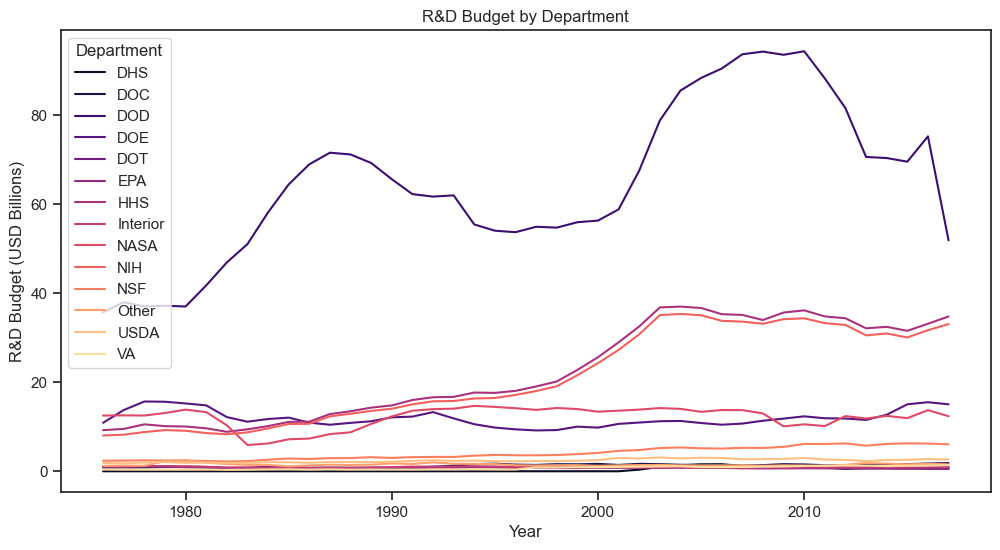

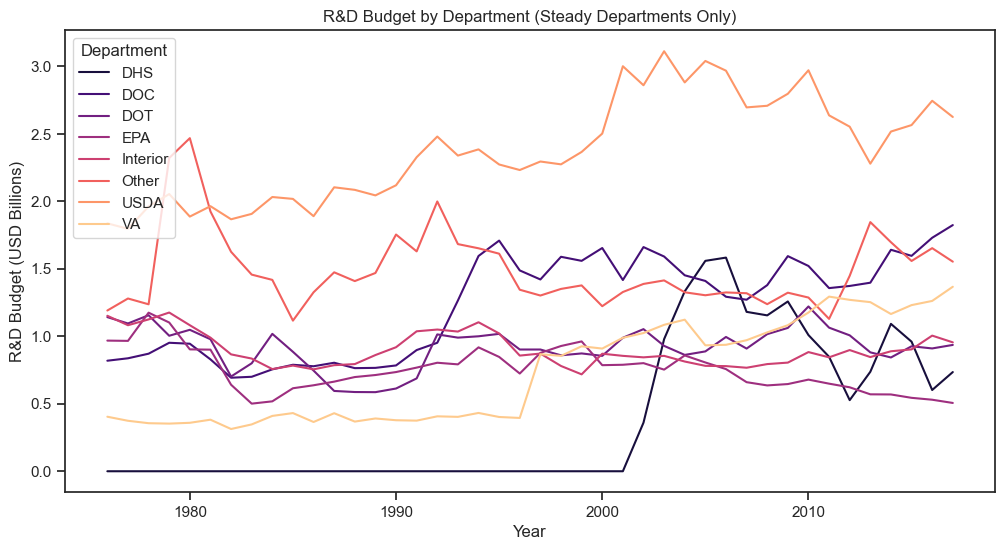

['DHS', 'DOC', 'DOD', 'DOE', 'DOT', 'EPA', 'HHS', 'Interior', 'NASA', 'NIH', 'NSF', 'Other', 'USDA', 'VA']


In [ ]:
# Create a visualization of the R&D budget for each department over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=dept_rd, 
             x='year', 
             y='rd_budget', 
             hue='department',
             palette='magma')

plt.title('R&D Budget by Department')
plt.xlabel('Year')
plt.ylabel('R&D Budget (USD Billions)')
plt.legend(title='Department')
plt.show()
dept_rd.head()

# Create a visualization highlighting the more steady department whoes R&D budget has not fluctuated as much over time
plt.figure(figsize=(12, 6))
# Use the first graph to check the departments with the most steady R&D budgets and include those departments in the second graph
steady_depts = ['VA','USDA','VA', 'Other', 'DHS','EPA', 'Interior', 'DOT', 'DOC']
sns.lineplot(data=dept_rd[dept_rd['department'].isin(steady_depts)],
             x='year',
             y='rd_budget',
             hue='department',
             palette='magma')       
plt.title('R&D Budget by Department (Steady Departments Only)')
plt.xlabel('Year')
plt.ylabel('R&D Budget (USD Billions)')
plt.legend(title='Department', loc='upper left')
plt.show()


💥 Takeaways 💥
1. Some departments show budgets that are more event driven. Their allocations ebb and flow in response to crises or other current events. For example,the DHS (Homeland Security) budget saw a spike in spending directly after 9/11, showing how the government reallocates capital to address  threats.

2. However, the 2nd chart shows some departments have steady budgets. For example, the Agriculture department (USDA) and Veterans Affairs department (VA), focus on projects like food supply or clinical care that seems to be given consistentinvestment regardless of the macro climate.

Now lets shift our focus to the relative distrabution of this spend and how it compares to GDP over time:


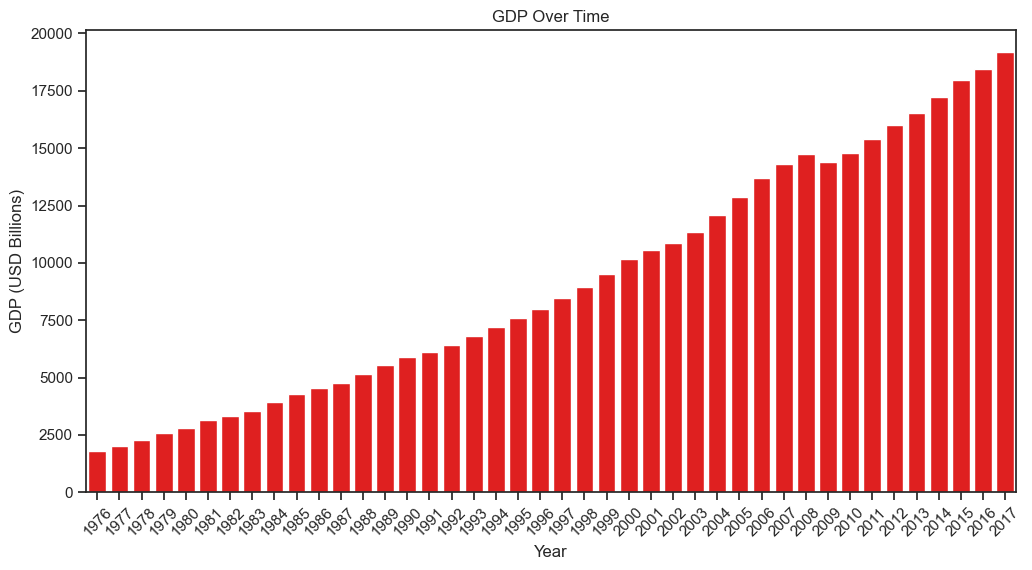

In [107]:
## Create a visualization of the GDP over time
plt.figure(figsize=(12, 6))
sns.barplot(data=gdp_by_year, x='year', y='gdp', color='red')
plt.xticks(rotation=45)
plt.title('GDP Over Time')
plt.xlabel('Year')
plt.ylabel('GDP (USD Billions)')
plt.show()  


⭐  This visualization displays that GDP is growing rapidly over the period of data period. Lets compare this with the growth in R&D over the same time frame.

In [113]:
# Use a pivot table to sum the total R&D budget across all departments by year
total_rd = dept_rd.pivot_table(
    index='year',
    values='rd_budget',
    aggfunc='sum'
).reset_index()
print(f'Total R&D Budget by Year:\n{total_rd}\n')

# find the pecentage of the total R&D budget compared to the GDP for each year
percentage_df = (
    total_rd
    #merge the total_rd and gdp_by_year data frames
    .merge(gdp_by_year, on='year')
    #divide total R&D budget by  the GDP for each year and assign that value to a new column called pct_of_gdp
    .assign(pct_of_gdp=lambda x: (x['rd_budget'] / x['gdp']) * 100)
)
print(f'Relative R&D Spending as a Percentage of GDP:\n{percentage_df}\n')


Total R&D Budget by Year:
    year  rd_budget
0   1976     86.227
1   1977     91.807
2   1978     94.864
3   1979     96.601
4   1980     96.305
5   1981     98.304
6   1982     95.448
7   1983     95.010
8   1984    105.371
9   1985    114.818
10  1986    118.231
11  1987    125.314
12  1988    126.800
13  1989    128.912
14  1990    129.126
15  1991    130.008
16  1992    133.172
17  1993    132.080
18  1994    127.278
19  1995    124.883
20  1996    123.978
21  1997    127.018
22  1998    129.698
23  1999    136.867
24  2000    142.299
25  2001    153.197
26  2002    170.354
27  2003    192.010
28  2004    199.104
29  2005    200.099
30  2006    199.429
31  2007    201.827
32  2008    200.857
33  2009    201.275
34  2010    204.556
35  2011    194.256
36  2012    188.944
37  2013    172.121
38  2014    175.383
39  2015    174.608
40  2016    185.885
41  2017    163.606

Relative R&D Spending as a Percentage of GDP:
    year  rd_budget      gdp  pct_of_gdp
0   1976     86.227   1790

⭐ The first table tells us that total R&D grew from 86.27 billion in 1976 to 163.606 in 2017. This is an impressive increase of 77 billion over 40 years. However the second table unlocks the a key insight provided by the dataset: 

💥 Takeaways 💥

The relative amount of R&D as a % of GDP has dramatically decreased from ~4.8% in 1976 to ~0.8% in 2017. 

The following plot seeks to portray that shift over time. 



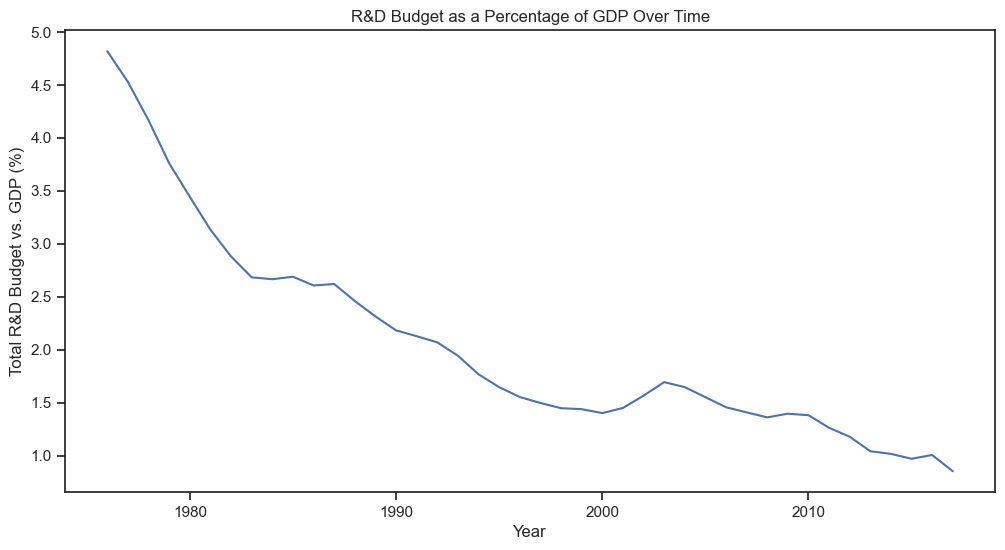

In [ ]:
#create a line plot to visualize the percentage of the total R&D budget compared to the GDP for each year
plt.figure(figsize=(12, 6))
sns.lineplot(data=percentage_df, x= 'year', y= 'pct_of_gdp')
plt.title('R&D Budget as a Percentage of GDP Over Time')
plt.xlabel('Year')
plt.ylabel('Total R&D Budget vs. GDP (%)')
plt.show()

⭐ This plot shows their is a decreasing relative amount of GDP spent on federal R&D year by year. Lets see how that stacks up by plotting both changes on the same plane.

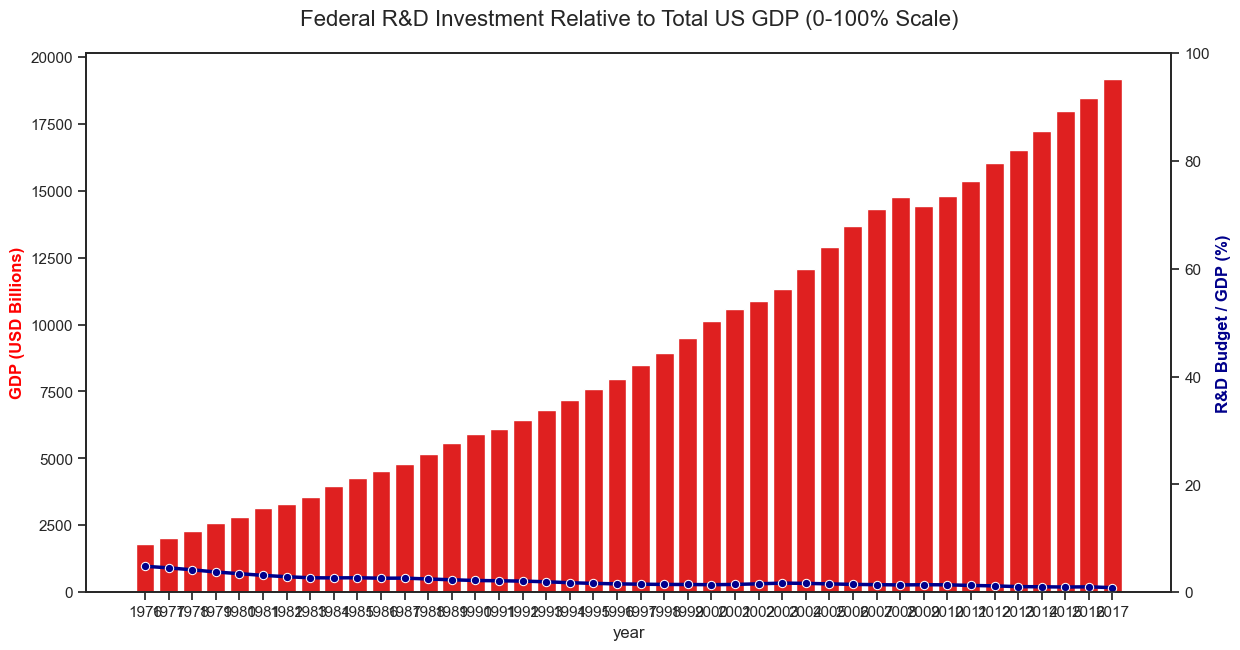

In [ ]:
#Create a visualization to show the % of the total R&D budget compared to the GDP for each year
fig, ax1 = plt.subplots(figsize=(14, 7))

#Plot GDP as Bars on the Left Axis
sns.barplot(data=percentage_df, x='year', y='gdp', color='red', ax=ax1)
ax1.set_ylabel('GDP (USD Billions)', color='red', fontweight='bold')
ax1.tick_params(axis='y')

#Create the secondary axis
ax2 = ax1.twinx()

#Plot R&D % as a Line on the Right Axis
sns.lineplot(x=range(len(percentage_df)), y=percentage_df['pct_of_gdp'], 
             color='darkblue', marker='o', ax=ax2, linewidth=2.5)


ax2.set_ylabel('R&D Budget / GDP (%)', color='darkblue', fontweight='bold')
ax2.tick_params(axis='y')

#Set the axsis range for the percentage of R&D budget compared to GDP to be between 0 and 100
ax2.set_ylim(0, 100)

plt.title('Federal R&D Investment Relative to Total US GDP (0-100% Scale)', fontsize=16, pad=20)
ax1.set_xticklabels(percentage_df['year'], rotation=45)

plt.show()

     year department  rd_budget  rd_budget_total  pct_of_total
0    1976        DHS      0.000           86.227      0.000000
1    1976        DOC      0.819           86.227      0.949819
2    1976        DOD     35.696           86.227     41.397706
3    1976        DOE     10.882           86.227     12.620177
4    1976        DOT      1.142           86.227      1.324411
..    ...        ...        ...              ...           ...
583  2017        NIH     33.052          163.606     20.202193
584  2017        NSF      6.040          163.606      3.691796
585  2017      Other      1.553          163.606      0.949232
586  2017       USDA      2.625          163.606      1.604464
587  2017         VA      1.367          163.606      0.835544

[588 rows x 5 columns]


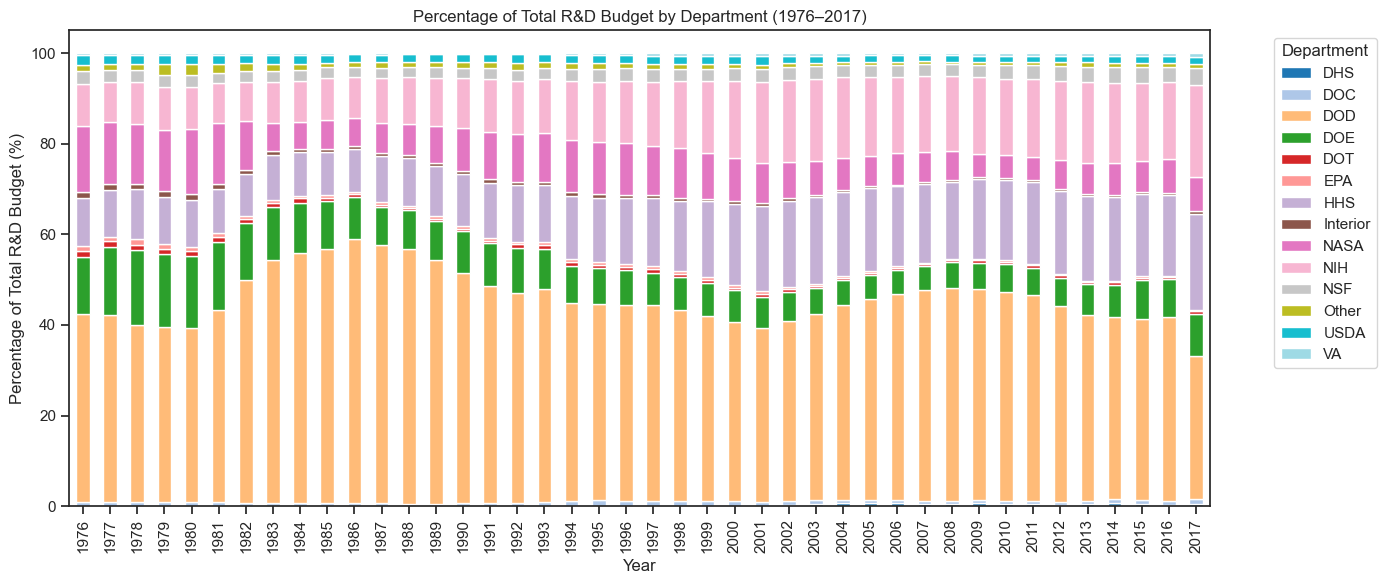

In [92]:
# Make a bar chart showing the percentage of each department of total R&D budget for each year
dept_percentage = (
    dept_rd
    # merge the dept_rd and total_rd data frames to get the total R&D budget for each year
    .merge(total_rd, on='year', suffixes=('', '_total'))
    # calculate the percentage of each department's R&D budget compared to the total R&D budget for each year and assign that value to a new column called pct_of_total
    .assign(pct_of_total=lambda x: (x['rd_budget'] / x['rd_budget_total']) * 100)
)
print(dept_percentage)

# create a bar chart showing the percentage of each department of total R&D budget for each year

# Pivot to wide format — each department becomes its own column
dept_pivot = dept_percentage.pivot(index='year', columns='department', values='pct_of_total')
dept_pivot.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
plt.title('Percentage of Total R&D Budget by Department (1976–2017)')
plt.xlabel('Year')
plt.ylabel('Percentage of Total R&D Budget (%)')
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
